In [8]:
import pandas as pd
import os

# Correct file path formatting (Use double backslashes or raw string)
file_path = r"C:\Users\shrey\OneDrive\Desktop\New folder\Intuilize_MNSU_ACME_QuotesData.csv"

try:
    # Check if the file exists
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Error: File not found at {file_path}")

    # Load the CSV file
    df = pd.read_csv(file_path, encoding='utf-8')

    # Drop null values
    df_cleaned = df.dropna()

    # Remove duplicate rows
    df_cleaned = df_cleaned.drop_duplicates()

    # Corrected file path for saving the new cleaned CSV file
    cleaned_file_path = r"C:\Users\shrey\OneDrive\Desktop\New folder\cleaned_quotes_data.csv"

    # Save the cleaned data
    df_cleaned.to_csv(cleaned_file_path, index=False)

    # Display first 5 rows of cleaned data (instead of ace_tools)
    print("\nCleaned Data (First 5 Rows):")
    print(df_cleaned.head())

    # Print the saved file location
    print(f"\n✅ Cleaned file saved at: {cleaned_file_path}")

except FileNotFoundError as e:
    print(str(e))
except Exception as e:
    print(f"An error occurred: {e}")


KeyboardInterrupt: 

In [7]:
import pandas as pd
import os

# Load the datasets
quotes_file_path = r"C:\Users\shrey\OneDrive\Desktop\New folder\Intuilize_MNSU_ACME_QuotesData.csv"
sales_file_path = r"C:\Users\shrey\OneDrive\Desktop\New folder\Intuilize_MNSU_ACME_SalesData.csv"

# Read CSV files
quotes_df = pd.read_csv(quotes_file_path)
sales_df = pd.read_csv(sales_file_path)

# Drop duplicate rows
quotes_df.drop_duplicates(inplace=True)
sales_df.drop_duplicates(inplace=True)

# Drop rows with missing values
quotes_df.dropna(inplace=True)
sales_df.dropna(inplace=True)

# Convert 'Quote Date' to datetime format
if 'Quote Date' in quotes_df.columns:
    quotes_df['Quote Date'] = pd.to_datetime(quotes_df['Quote Date'])
    quotes_df['Quote Year'] = quotes_df['Quote Date'].dt.year
    quotes_df['Quote Month'] = quotes_df['Quote Date'].dt.month
    quotes_df['Quote Day'] = quotes_df['Quote Date'].dt.day

# Merge Sales and Quotes Data based on 'Quote ID'
if 'Quote ID' in quotes_df.columns and 'Quote ID' in sales_df.columns:
    merged_df = quotes_df.merge(sales_df, on="Quote ID", how="left")
else:
    merged_df = quotes_df  # Use quotes data alone if no matching column

# Create target variable 'Converted'
if 'Sale ID' in merged_df.columns:  
    merged_df['Converted'] = merged_df['Sale ID'].notnull().astype(int)

# Save the cleaned & merged dataset to a new CSV file in a valid location
cleaned_file_path = r"C:\Users\shrey\OneDrive\Desktop\cleaned_quotes_data.csv"
merged_df.to_csv(cleaned_file_path, index=False)

# Confirm successful saving
print(f"✅ Cleaned file saved successfully at: {cleaned_file_path}")


C:\Users\shrey\AppData\Local\Temp\ipykernel_28676\1089423838.py:9: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  quotes_df = pd.read_csv(quotes_file_path)


✅ Cleaned file saved successfully at: C:\Users\shrey\OneDrive\Desktop\cleaned_quotes_data.csv


In [10]:
import pandas as pd

# Load the cleaned dataset
cleaned_file_path = r"C:\Users\shrey\OneDrive\Desktop\cleaned_quotes_data.csv"
df = pd.read_csv(cleaned_file_path)

# Show all column names
print(" Available Columns in the Cleaned Data:")
print(df.columns)

# Display first few rows
print("\n Sample Data:")
print(df.head())


 Available Columns in the Cleaned Data:
Index(['QuoteID', 'QuoteVersion', 'QuoteDate', 'ExpirationDate',
       'SalesPersonID', 'SalesPersonName', 'CustomerID', 'CustomerName',
       'BranchName', 'Ship2City', 'Ship2State', 'ProductID', 'ProductGroupID',
       'QuoteQty', 'UnitPrice', 'UOM', 'UnitSize', 'QuoteStatus',
       'ConvertedToOrderNumber', 'ConversionDate'],
      dtype='object')

 Sample Data:
     QuoteID  QuoteVersion   QuoteDate ExpirationDate SalesPersonID  \
0  Q00000000             1  2024-12-26     2024-12-27         SREP1   
1  Q00000001             1  2024-12-23     2025-01-17         SREP1   
2  Q00000002             1  2024-12-31     2025-01-14         SREP1   
3  Q00000003             1  2024-12-22     2024-12-27         SREP1   
4  Q00000004             1  2024-12-17     2025-01-06         SREP1   

  SalesPersonName CustomerID                CustomerName        BranchName  \
0  MELISSA MACIAS      CUST1  BROWN, BURKE AND SMITH LLC  JOHNHAVEN BRANCH   
1  ME

🛠️ First Few Rows of Cleaned Data:
     QuoteID  QuoteVersion   QuoteDate ExpirationDate SalesPersonID  \
0  Q00000000             1  2024-12-26     2024-12-27         SREP1   
1  Q00000001             1  2024-12-23     2025-01-17         SREP1   
2  Q00000002             1  2024-12-31     2025-01-14         SREP1   
3  Q00000003             1  2024-12-22     2024-12-27         SREP1   
4  Q00000004             1  2024-12-17     2025-01-06         SREP1   

  SalesPersonName CustomerID                CustomerName        BranchName  \
0  MELISSA MACIAS      CUST1  BROWN, BURKE AND SMITH LLC  JOHNHAVEN BRANCH   
1  MELISSA MACIAS      CUST1  BROWN, BURKE AND SMITH LLC  JOHNHAVEN BRANCH   
2  MELISSA MACIAS      CUST1  BROWN, BURKE AND SMITH LLC  JOHNHAVEN BRANCH   
3  MELISSA MACIAS      CUST1  BROWN, BURKE AND SMITH LLC  JOHNHAVEN BRANCH   
4  MELISSA MACIAS      CUST1  BROWN, BURKE AND SMITH LLC  JOHNHAVEN BRANCH   

   Ship2City  ...    ProductID ProductGroupID QuoteQty  UnitPrice  UO

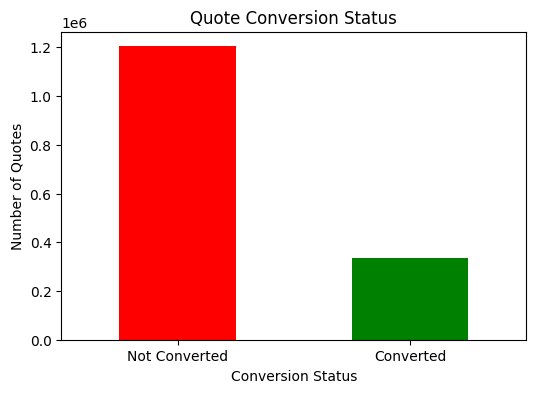

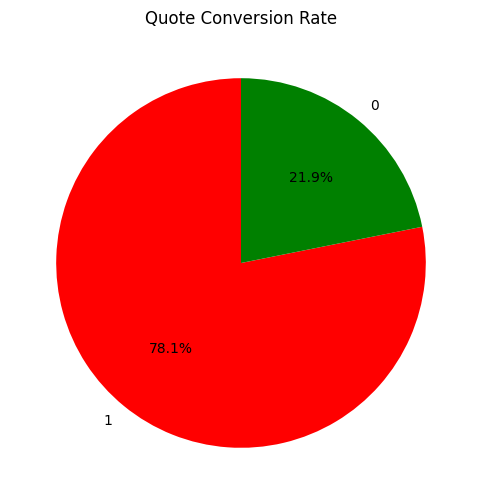

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the cleaned dataset (update path if needed)
cleaned_file_path = r"C:\Users\shrey\OneDrive\Desktop\cleaned_quotes_data.csv"
df_cleaned = pd.read_csv(cleaned_file_path)

# Display the cleaned data (Replaces ace_tools)
print("🛠️ First Few Rows of Cleaned Data:")
print(df_cleaned.head())

# Checking if 'Won' column exists and creating 'Converted' column
if 'Won' in df_cleaned.columns and 'Converted' not in df_cleaned.columns:
    df_cleaned['Converted'] = df_cleaned['Won'].apply(lambda x: 1 if x == 'Yes' else 0)

# 1️⃣ **Bar Chart: Converted vs. Not Converted Quotes**
plt.figure(figsize=(6, 4))
df_cleaned['Converted'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.xticks(ticks=[0, 1], labels=["Not Converted", "Converted"], rotation=0)
plt.title("Quote Conversion Status")
plt.ylabel("Number of Quotes")
plt.xlabel("Conversion Status")
plt.show()

# 2️⃣ **Pie Chart: Percentage of Converted vs. Not Converted Quotes**
plt.figure(figsize=(6, 6))
df_cleaned['Converted'].value_counts().plot.pie(
    autopct='%1.1f%%', startangle=90, colors=['red', 'green'])
plt.title("Quote Conversion Rate")
plt.ylabel("")
plt.show()

# 3️⃣ **Histogram: Distribution of Quote Amounts for Converted vs. Not Converted**
if 'Quote Amount' in df_cleaned.columns:
    plt.figure(figsize=(8, 5))
    df_cleaned[df_cleaned['Converted'] == 1]['Quote Amount'].hist(bins=30, alpha=0.7, color='green', label='Converted')
    df_cleaned[df_cleaned['Converted'] == 0]['Quote Amount'].hist(bins=30, alpha=0.7, color='red', label='Not Converted')
    plt.title("Distribution of Quote Amounts by Conversion Status")
    plt.xlabel("Quote Amount ($)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

# 4️⃣ **Box Plot: Quote Amounts for Converted vs. Not Converted Quotes**
if 'Quote Amount' in df_cleaned.columns:
    plt.figure(figsize=(6, 5))
    df_cleaned.boxplot(column='Quote Amount', by='Converted', grid=False, patch_artist=True)
    plt.xticks(ticks=[1, 2], labels=["Not Converted", "Converted"])
    plt.title("Quote Amount Distribution by Conversion Status")
    plt.xlabel("Conversion Status")
    plt.ylabel("Quote Amount ($)")
    plt.suptitle("")  # Removes default title
    plt.show()


In [13]:
import pandas as pd

# Load the cleaned dataset
cleaned_file_path = r"C:\Users\shrey\OneDrive\Desktop\cleaned_quotes_data.csv"
df_cleaned = pd.read_csv(cleaned_file_path)

# Display available column names
print("🔍 Available Columns in Dataset:")
print(df_cleaned.columns)

# Show first few rows to inspect the structure
print("\n🛠️ Sample Data:")
print(df_cleaned.head())


🔍 Available Columns in Dataset:
Index(['QuoteID', 'QuoteVersion', 'QuoteDate', 'ExpirationDate',
       'SalesPersonID', 'SalesPersonName', 'CustomerID', 'CustomerName',
       'BranchName', 'Ship2City', 'Ship2State', 'ProductID', 'ProductGroupID',
       'QuoteQty', 'UnitPrice', 'UOM', 'UnitSize', 'QuoteStatus',
       'ConvertedToOrderNumber', 'ConversionDate'],
      dtype='object')

🛠️ Sample Data:
     QuoteID  QuoteVersion   QuoteDate ExpirationDate SalesPersonID  \
0  Q00000000             1  2024-12-26     2024-12-27         SREP1   
1  Q00000001             1  2024-12-23     2025-01-17         SREP1   
2  Q00000002             1  2024-12-31     2025-01-14         SREP1   
3  Q00000003             1  2024-12-22     2024-12-27         SREP1   
4  Q00000004             1  2024-12-17     2025-01-06         SREP1   

  SalesPersonName CustomerID                CustomerName        BranchName  \
0  MELISSA MACIAS      CUST1  BROWN, BURKE AND SMITH LLC  JOHNHAVEN BRANCH   
1  MELISSA 

In [14]:
# Ensure 'Converted' column exists
if 'QuoteStatus' in df_cleaned.columns:
    df_cleaned['Converted'] = df_cleaned['QuoteStatus'].apply(lambda x: 1 if x == 'Won' else 0)
    print("✅ 'Converted' column created successfully!")
else:
    print("❌ 'QuoteStatus' column not found! Check dataset manually.")

# Save the updated dataset
df_cleaned.to_csv(cleaned_file_path, index=False)
print(f"✅ Updated dataset saved with 'Converted' column at {cleaned_file_path}")


✅ 'Converted' column created successfully!
✅ Updated dataset saved with 'Converted' column at C:\Users\shrey\OneDrive\Desktop\cleaned_quotes_data.csv
